# 12 — Compare Skeleton GaitTR vs Silhouette GaitGL Experts — FULL FIXED

এই notebook আপনার দুই expert-এর result compare করবে:

```text
Skeleton expert   : GaitTR
Silhouette expert : GaitGL-style silhouette expert
```

It produces condition-wise comparison, winner analysis, plots, and a fusion recommendation report.

Default skeleton values are manually set from your previous evaluated result:

```text
Skeleton GaitTR: NM=94.91, BG=79.27, CL=75.18
```

Silhouette values are loaded automatically from:

```text
results/gaitgl_silhouette_eval/gaitgl_LT_silhouette_checkpoint_comparison.csv
```

Outputs:

```text
results/expert_comparison/expert_rank1_comparison.csv
results/expert_comparison/expert_rank1_difference.csv
results/expert_comparison/fusion_recommendation.json
results/expert_comparison/expert_comparison_report.md
results/expert_comparison/plots/*.png
```

In [1]:
# ============================================================
# CELL 1 — Imports and config
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")
RESULT_DIR = EXP_DIR / "results"
COMPARISON_DIR = RESULT_DIR / "expert_comparison"
PLOT_DIR = COMPARISON_DIR / "plots"
DETAIL_DIR = COMPARISON_DIR / "details"

for d in [COMPARISON_DIR, PLOT_DIR, DETAIL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CONDITIONS = ["NM", "BG", "CL"]

# ------------------------------------------------------------
# Skeleton results
# ------------------------------------------------------------
# Keep True if you want to use your already-known skeleton/GaitTR numbers.
USE_MANUAL_SKELETON_RESULTS = True

MANUAL_SKELETON_RESULTS = {
    "model": "Skeleton GaitTR",
    "checkpoint": "selected_skeleton_checkpoint",
    "NM": 94.91,
    "BG": 79.27,
    "CL": 75.18,
}

# If you have a skeleton comparison CSV, set USE_MANUAL_SKELETON_RESULTS=False
# and set exact path here.
SKELETON_COMPARISON_CSV = None

# ------------------------------------------------------------
# Silhouette results
# ------------------------------------------------------------
SIL_EVAL_DIR = RESULT_DIR / "gaitgl_silhouette_eval"
SIL_COMPARISON_CSV = SIL_EVAL_DIR / "gaitgl_LT_silhouette_checkpoint_comparison.csv"

AUTO_SELECT_BEST_SILHOUETTE = True
PREFERRED_SIL_CHECKPOINT = "gaitgl_LT_silhouette_best_loss.pth"

print("=" * 80)
print("Compare Skeleton GaitTR vs Silhouette GaitGL")
print("=" * 80)
print("EXP_DIR:", EXP_DIR)
print("SIL_COMPARISON_CSV:", SIL_COMPARISON_CSV)
print("USE_MANUAL_SKELETON_RESULTS:", USE_MANUAL_SKELETON_RESULTS)
print("=" * 80)

Compare Skeleton GaitTR vs Silhouette GaitGL
EXP_DIR: /media/wadud/DriveUbuntu/GaitRecognition 2.0
SIL_COMPARISON_CSV: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/gaitgl_LT_silhouette_checkpoint_comparison.csv
USE_MANUAL_SKELETON_RESULTS: True


In [2]:
# ============================================================
# CELL 2 — Robust metric loading helpers
# ============================================================

def to_percent(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, str):
        x = x.strip().replace("%", "")
    v = float(x)
    if v <= 1.0:
        v *= 100.0
    return v

def first_col(df, names):
    low = {c.lower(): c for c in df.columns}
    for n in names:
        if n in df.columns:
            return n
        if n.lower() in low:
            return low[n.lower()]
    return None

def load_manual_skeleton():
    rows = []
    for c in CONDITIONS:
        rows.append({
            "expert": "Skeleton",
            "model": MANUAL_SKELETON_RESULTS["model"],
            "checkpoint": MANUAL_SKELETON_RESULTS["checkpoint"],
            "condition": c,
            "rank1_percent": to_percent(MANUAL_SKELETON_RESULTS[c]),
            "source": "manual_config",
        })
    return pd.DataFrame(rows)

def load_skeleton_from_csv(path):
    path = Path(path)
    df = pd.read_csv(path)

    ckpt_col = first_col(df, ["checkpoint", "checkpoint_name", "model", "name"])

    cond_cols = {
        c: first_col(df, [
            f"rank1_{c}_percent",
            f"rank1_{c}",
            f"{c}_rank1_percent",
            c,
            c.lower(),
        ])
        for c in CONDITIONS
    }

    if all(cond_cols[c] is not None for c in CONDITIONS):
        mean_col = first_col(df, ["mean_rank1_percent", "mean_rank1"])
        tmp = df.copy()

        if mean_col:
            tmp["_mean"] = tmp[mean_col].apply(to_percent)
        else:
            tmp["_mean"] = tmp[[cond_cols[c] for c in CONDITIONS]].apply(
                lambda r: np.mean([to_percent(v) for v in r]), axis=1
            )

        best = tmp.sort_values("_mean", ascending=False).iloc[0]
        ckpt = str(best[ckpt_col]) if ckpt_col else path.name

        return pd.DataFrame([
            {
                "expert": "Skeleton",
                "model": "Skeleton GaitTR",
                "checkpoint": ckpt,
                "condition": c,
                "rank1_percent": to_percent(best[cond_cols[c]]),
                "source": str(path),
            }
            for c in CONDITIONS
        ])

    cond_col = first_col(df, ["condition", "probe_condition"])
    rank_col = first_col(df, ["rank1_percent", "rank1", "accuracy", "acc"])

    if cond_col and rank_col:
        rows = []
        for c in CONDITIONS:
            sub = df[df[cond_col].astype(str).str.upper() == c]
            if len(sub) == 0:
                continue
            r = sub.iloc[0]
            rows.append({
                "expert": "Skeleton",
                "model": "Skeleton GaitTR",
                "checkpoint": str(r[ckpt_col]) if ckpt_col else path.name,
                "condition": c,
                "rank1_percent": to_percent(r[rank_col]),
                "source": str(path),
            })
        if len(rows) == len(CONDITIONS):
            return pd.DataFrame(rows)

    raise ValueError(f"Could not parse skeleton CSV: {path}")

def auto_find_skeleton_csv():
    if not RESULT_DIR.exists():
        return None

    candidates = []
    for p in RESULT_DIR.rglob("*.csv"):
        s = str(p).lower()
        name = p.name.lower()
        if ("silhouette" in s) or ("gaitgl" in s):
            continue
        if (("gaittr" in s) or ("skeleton" in s)) and (("comparison" in name) or ("summary" in name)):
            candidates.append(p)

    candidates = sorted(candidates, key=lambda p: len(str(p)))
    return candidates[0] if candidates else None

def load_skeleton_results():
    if USE_MANUAL_SKELETON_RESULTS:
        return load_manual_skeleton()

    if SKELETON_COMPARISON_CSV is not None and Path(SKELETON_COMPARISON_CSV).exists():
        return load_skeleton_from_csv(SKELETON_COMPARISON_CSV)

    found = auto_find_skeleton_csv()
    if found is not None:
        print("Auto-found skeleton result CSV:", found)
        return load_skeleton_from_csv(found)

    raise FileNotFoundError(
        "No skeleton result CSV found. Set USE_MANUAL_SKELETON_RESULTS=True "
        "or set SKELETON_COMPARISON_CSV."
    )

def load_silhouette_results():
    assert SIL_COMPARISON_CSV.exists(), f"Missing: {SIL_COMPARISON_CSV}"

    df = pd.read_csv(SIL_COMPARISON_CSV)

    required = ["checkpoint", "rank1_NM_percent", "rank1_BG_percent", "rank1_CL_percent"]
    missing = [c for c in required if c not in df.columns]
    assert not missing, f"Silhouette comparison missing columns: {missing}"

    if "mean_rank1_percent" not in df.columns:
        df["mean_rank1_percent"] = df[[
            "rank1_NM_percent",
            "rank1_BG_percent",
            "rank1_CL_percent",
        ]].mean(axis=1)

    if AUTO_SELECT_BEST_SILHOUETTE:
        best = df.sort_values("mean_rank1_percent", ascending=False).iloc[0]
    else:
        sub = df[df["checkpoint"].astype(str) == PREFERRED_SIL_CHECKPOINT]
        assert len(sub) > 0, f"Preferred silhouette checkpoint not found: {PREFERRED_SIL_CHECKPOINT}"
        best = sub.iloc[0]

    out = pd.DataFrame([
        {
            "expert": "Silhouette",
            "model": "GaitGL-style silhouette",
            "checkpoint": str(best["checkpoint"]),
            "condition": c,
            "rank1_percent": to_percent(best[f"rank1_{c}_percent"]),
            "source": str(SIL_COMPARISON_CSV),
        }
        for c in CONDITIONS
    ])

    return out, df, best

In [3]:
# ============================================================
# CELL 3 — Load skeleton and silhouette results
# ============================================================

df_skeleton = load_skeleton_results()
df_silhouette, df_sil_all, sil_best = load_silhouette_results()

print("Skeleton result:")
display(df_skeleton)

print("All silhouette checkpoints:")
display(df_sil_all[[
    "checkpoint",
    "rank1_NM_percent",
    "rank1_BG_percent",
    "rank1_CL_percent",
    "mean_rank1_percent",
]])

print("Selected silhouette checkpoint:", sil_best["checkpoint"])
print("Selected silhouette result:")
display(df_silhouette)

Skeleton result:


,expert,model,checkpoint,condition,rank1_percent,source
0,Skeleton,Skeleton GaitTR,selected_skeleton_checkpoint,NM,94.91,manual_config
1,Skeleton,Skeleton GaitTR,selected_skeleton_checkpoint,BG,79.27,manual_config
2,Skeleton,Skeleton GaitTR,selected_skeleton_checkpoint,CL,75.18,manual_config


All silhouette checkpoints:


,checkpoint,rank1_NM_percent,rank1_BG_percent,rank1_CL_percent,mean_rank1_percent
0,gaitgl_LT_silhouette_best_loss.pth,97.545455,85.454545,65.909091,82.969697
1,gaitgl_LT_silhouette_last.pth,97.545455,85.636364,65.545455,82.909091
2,gaitgl_LT_silhouette_full_last.pth,97.545455,85.636364,65.545455,82.909091
3,gaitgl_LT_silhouette_best_train_acc.pth,88.454545,65.818182,45.727273,66.666667


Selected silhouette checkpoint: gaitgl_LT_silhouette_best_loss.pth
Selected silhouette result:


,expert,model,checkpoint,condition,rank1_percent,source
0,Silhouette,GaitGL-style silhouette,gaitgl_LT_silhouette_best_loss.pth,NM,97.545455,/media/wadud/DriveUbuntu/GaitRecognition 2.0/r...
1,Silhouette,GaitGL-style silhouette,gaitgl_LT_silhouette_best_loss.pth,BG,85.454545,/media/wadud/DriveUbuntu/GaitRecognition 2.0/r...
2,Silhouette,GaitGL-style silhouette,gaitgl_LT_silhouette_best_loss.pth,CL,65.909091,/media/wadud/DriveUbuntu/GaitRecognition 2.0/r...


In [4]:
# ============================================================
# CELL 4 — Build comparison table
# ============================================================

df_all = pd.concat([df_skeleton, df_silhouette], ignore_index=True)

df_wide = (
    df_all
    .pivot_table(
        index="condition",
        columns="expert",
        values="rank1_percent",
        aggfunc="first",
    )
    .reset_index()
)

df_wide["condition"] = pd.Categorical(df_wide["condition"], categories=CONDITIONS, ordered=True)
df_wide = df_wide.sort_values("condition").reset_index(drop=True)

df_wide["Silhouette_minus_Skeleton"] = df_wide["Silhouette"] - df_wide["Skeleton"]
df_wide["winner"] = np.where(df_wide["Silhouette_minus_Skeleton"] >= 0, "Silhouette", "Skeleton")
df_wide["absolute_gap"] = df_wide["Silhouette_minus_Skeleton"].abs()

skeleton_mean = float(df_wide["Skeleton"].mean())
silhouette_mean = float(df_wide["Silhouette"].mean())

df_mean = pd.DataFrame([
    {
        "expert": "Skeleton",
        "NM": float(df_wide.loc[df_wide["condition"] == "NM", "Skeleton"].iloc[0]),
        "BG": float(df_wide.loc[df_wide["condition"] == "BG", "Skeleton"].iloc[0]),
        "CL": float(df_wide.loc[df_wide["condition"] == "CL", "Skeleton"].iloc[0]),
        "mean_rank1_percent": skeleton_mean,
    },
    {
        "expert": "Silhouette",
        "NM": float(df_wide.loc[df_wide["condition"] == "NM", "Silhouette"].iloc[0]),
        "BG": float(df_wide.loc[df_wide["condition"] == "BG", "Silhouette"].iloc[0]),
        "CL": float(df_wide.loc[df_wide["condition"] == "CL", "Silhouette"].iloc[0]),
        "mean_rank1_percent": silhouette_mean,
    },
])

comparison_csv = COMPARISON_DIR / "expert_rank1_comparison.csv"
difference_csv = COMPARISON_DIR / "expert_rank1_difference.csv"
mean_csv = COMPARISON_DIR / "expert_mean_summary.csv"

df_all.to_csv(comparison_csv, index=False)
df_wide.to_csv(difference_csv, index=False)
df_mean.to_csv(mean_csv, index=False)

print("Condition-wise comparison:")
display(df_wide)

print("Mean summary:")
display(df_mean)

print("Saved:", comparison_csv)
print("Saved:", difference_csv)
print("Saved:", mean_csv)

Condition-wise comparison:


expert,condition,Silhouette,Skeleton,Silhouette_minus_Skeleton,winner,absolute_gap
0,NM,97.545455,94.91,2.635455,Silhouette,2.635455
1,BG,85.454545,79.27,6.184545,Silhouette,6.184545
2,CL,65.909091,75.18,-9.270909,Skeleton,9.270909


Mean summary:


,expert,NM,BG,CL,mean_rank1_percent
0,Skeleton,94.910000,79.270000,75.180000,83.120000
1,Silhouette,97.545455,85.454545,65.909091,82.969697


Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/expert_comparison/expert_rank1_comparison.csv
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/expert_comparison/expert_rank1_difference.csv
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/expert_comparison/expert_mean_summary.csv


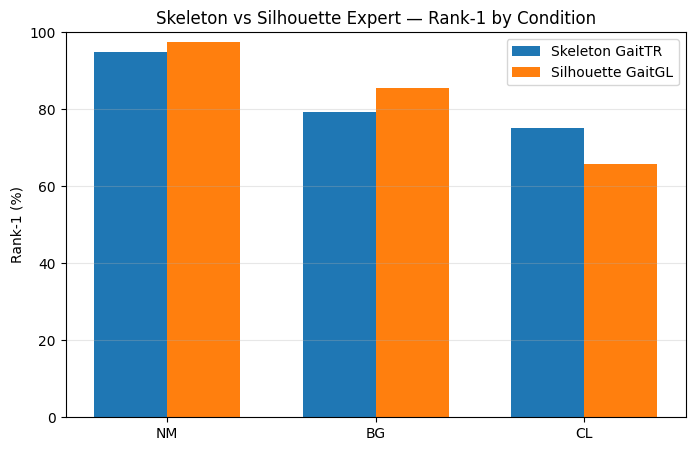

Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/expert_comparison/plots/rank1_grouped_bar.png


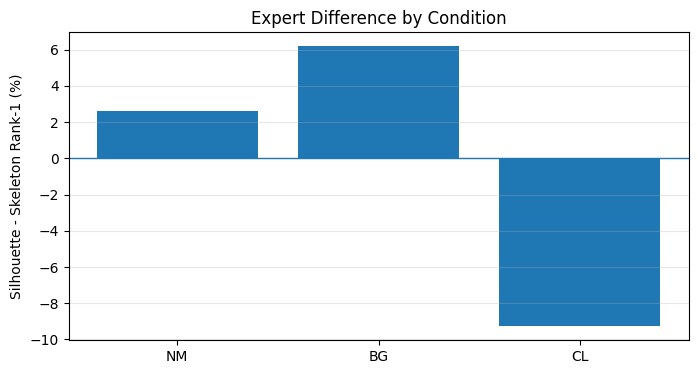

Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/expert_comparison/plots/rank1_difference_bar.png


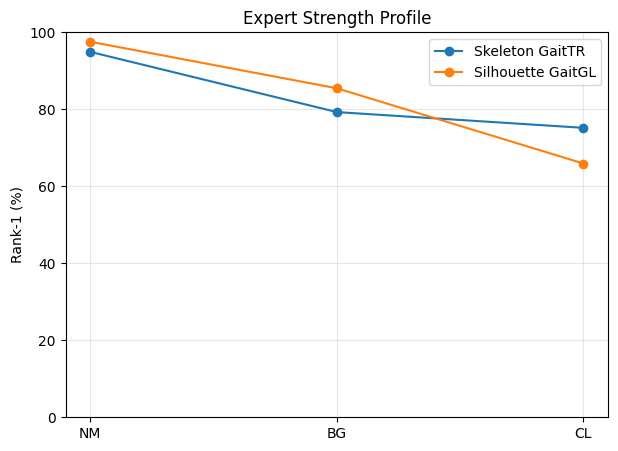

Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/expert_comparison/plots/expert_strength_profile.png


In [5]:
# ============================================================
# CELL 5 — Plots
# ============================================================

x = np.arange(len(df_wide))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, df_wide["Skeleton"], width, label="Skeleton GaitTR")
plt.bar(x + width / 2, df_wide["Silhouette"], width, label="Silhouette GaitGL")
plt.xticks(x, df_wide["condition"].astype(str))
plt.ylabel("Rank-1 (%)")
plt.ylim(0, 100)
plt.title("Skeleton vs Silhouette Expert — Rank-1 by Condition")
plt.grid(axis="y", alpha=0.3)
plt.legend()
p1 = PLOT_DIR / "rank1_grouped_bar.png"
plt.savefig(p1, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", p1)

plt.figure(figsize=(8, 4))
plt.bar(df_wide["condition"].astype(str), df_wide["Silhouette_minus_Skeleton"])
plt.axhline(0, linewidth=1)
plt.ylabel("Silhouette - Skeleton Rank-1 (%)")
plt.title("Expert Difference by Condition")
plt.grid(axis="y", alpha=0.3)
p2 = PLOT_DIR / "rank1_difference_bar.png"
plt.savefig(p2, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", p2)

plt.figure(figsize=(7, 5))
plt.plot(df_wide["condition"].astype(str), df_wide["Skeleton"], marker="o", label="Skeleton GaitTR")
plt.plot(df_wide["condition"].astype(str), df_wide["Silhouette"], marker="o", label="Silhouette GaitGL")
plt.ylabel("Rank-1 (%)")
plt.ylim(0, 100)
plt.title("Expert Strength Profile")
plt.grid(True, alpha=0.3)
plt.legend()
p3 = PLOT_DIR / "expert_strength_profile.png"
plt.savefig(p3, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", p3)

In [6]:
# ============================================================
# CELL 6 — Fusion recommendation
# ============================================================

recommendations = []

for _, r in df_wide.iterrows():
    cond = str(r["condition"])
    diff = float(r["Silhouette_minus_Skeleton"])
    winner = str(r["winner"])

    if cond in ["NM", "BG"] and winner == "Silhouette":
        note = (
            f"{cond}: Silhouette is stronger by {abs(diff):.2f} percentage points. "
            f"Fusion gate should prefer silhouette for this condition."
        )
    elif cond == "CL" and winner == "Skeleton":
        note = (
            f"{cond}: Skeleton is stronger by {abs(diff):.2f} percentage points. "
            f"Fusion gate should reduce silhouette weight under clothing variation."
        )
    else:
        note = (
            f"{cond}: {winner} is stronger by {abs(diff):.2f} percentage points. "
            f"Fusion should conditionally use this expert more."
        )

    recommendations.append({
        "condition": cond,
        "skeleton_rank1": float(r["Skeleton"]),
        "silhouette_rank1": float(r["Silhouette"]),
        "silhouette_minus_skeleton": diff,
        "winner": winner,
        "recommendation": note,
    })

df_recommend = pd.DataFrame(recommendations)

condition_level_oracle_mean = float(np.mean([
    max(r["skeleton_rank1"], r["silhouette_rank1"])
    for _, r in df_recommend.iterrows()
]))

best_single_mean = max(skeleton_mean, silhouette_mean)
possible_gain = condition_level_oracle_mean - best_single_mean

fusion_summary = {
    "skeleton_mean_rank1_percent": skeleton_mean,
    "silhouette_mean_rank1_percent": silhouette_mean,
    "best_single_expert": "Skeleton" if skeleton_mean >= silhouette_mean else "Silhouette",
    "best_single_expert_mean_rank1_percent": best_single_mean,
    "condition_level_oracle_mean_rank1_percent": condition_level_oracle_mean,
    "condition_level_possible_gain_percent": possible_gain,
    "selected_silhouette_checkpoint": str(sil_best["checkpoint"]),
    "recommendations": recommendations,
}

recommend_csv = COMPARISON_DIR / "fusion_recommendation_table.csv"
recommend_json = COMPARISON_DIR / "fusion_recommendation.json"

df_recommend.to_csv(recommend_csv, index=False)
with open(recommend_json, "w") as f:
    json.dump(fusion_summary, f, indent=2)

print("Fusion recommendation:")
display(df_recommend)

print(json.dumps(fusion_summary, indent=2))
print("Saved:", recommend_csv)
print("Saved:", recommend_json)

Fusion recommendation:


,condition,skeleton_rank1,silhouette_rank1,silhouette_minus_skeleton,winner,recommendation
0,NM,94.91,97.545455,2.635455,Silhouette,NM: Silhouette is stronger by 2.64 percentage ...
1,BG,79.27,85.454545,6.184545,Silhouette,BG: Silhouette is stronger by 6.18 percentage ...
2,CL,75.18,65.909091,-9.270909,Skeleton,CL: Skeleton is stronger by 9.27 percentage po...


{
  "skeleton_mean_rank1_percent": 83.12,
  "silhouette_mean_rank1_percent": 82.96969696969697,
  "best_single_expert": "Skeleton",
  "best_single_expert_mean_rank1_percent": 83.12,
  "condition_level_oracle_mean_rank1_percent": 86.06,
  "condition_level_possible_gain_percent": 2.9399999999999977,
  "selected_silhouette_checkpoint": "gaitgl_LT_silhouette_best_loss.pth",
  "recommendations": [
    {
      "condition": "NM",
      "skeleton_rank1": 94.91,
      "silhouette_rank1": 97.54545454545456,
      "silhouette_minus_skeleton": 2.6354545454545644,
      "winner": "Silhouette",
      "recommendation": "NM: Silhouette is stronger by 2.64 percentage points. Fusion gate should prefer silhouette for this condition."
    },
    {
      "condition": "BG",
      "skeleton_rank1": 79.27,
      "silhouette_rank1": 85.45454545454545,
      "silhouette_minus_skeleton": 6.184545454545457,
      "winner": "Silhouette",
      "recommendation": "BG: Silhouette is stronger by 6.18 percentage points

In [7]:
# ============================================================
# CELL 7 — Optional detailed complementarity if detail files exist
# ============================================================

def find_sil_detail(cond):
    ckpt_stem = Path(str(sil_best["checkpoint"])).stem
    details_dir = SIL_EVAL_DIR / "details"
    if not details_dir.exists():
        return None

    candidates = sorted(details_dir.glob(f"{ckpt_stem}_{cond}_probe_details.csv"))
    if candidates:
        return candidates[0]

    candidates = sorted(details_dir.glob(f"*{ckpt_stem}*{cond}*details*.csv"))
    return candidates[0] if candidates else None

def find_skel_detail(cond):
    # Auto-search only. If not found, this cell skips sample-level oracle.
    candidates = []
    for p in RESULT_DIR.rglob("*.csv"):
        s = str(p).lower()
        name = p.name.lower()
        if "silhouette" in s or "gaitgl" in s:
            continue
        if cond.lower() in name and ("detail" in name or "probe" in name) and ("gaittr" in s or "skeleton" in s):
            candidates.append(p)
    candidates = sorted(candidates, key=lambda p: len(str(p)))
    return candidates[0] if candidates else None

def normalize_detail(df, prefix):
    subj_col = first_col(df, ["probe_subject", "subject"])
    view_col = first_col(df, ["probe_view", "view"])
    cond_col = first_col(df, ["probe_condition", "condition"])
    seq_col = first_col(df, ["probe_seq", "seq"])
    correct_col = first_col(df, ["rank1_correct", "top1_correct", "correct", "is_correct"])
    path_col = first_col(df, ["probe_silhouette_path", "probe_path", "silhouette_path", "pose_path", "path"])

    if subj_col is None or view_col is None or correct_col is None:
        raise ValueError("Detail CSV schema not supported.")

    out = pd.DataFrame()
    out["probe_subject"] = df[subj_col].astype(str)
    out["probe_view"] = df[view_col].astype(str)
    out["probe_condition"] = df[cond_col].astype(str) if cond_col else ""
    out["probe_seq"] = df[seq_col].astype(str) if seq_col else ""
    out["probe_path"] = df[path_col].astype(str) if path_col else ""

    def as_bool(x):
        if pd.isna(x):
            return False
        if isinstance(x, str):
            return x.strip().lower() in ["true", "1", "yes", "correct"]
        return bool(x)

    out[f"{prefix}_correct"] = df[correct_col].apply(as_bool)

    if out["probe_path"].astype(str).str.len().max() > 0:
        out["probe_key"] = out["probe_path"].astype(str)
    else:
        out["probe_key"] = (
            out["probe_subject"] + "-" +
            out["probe_condition"] + "-" +
            out["probe_seq"] + "-" +
            out["probe_view"]
        )

    return out[["probe_key", f"{prefix}_correct"]]

detail_rows = []
oracle_rows = []

for cond in CONDITIONS:
    sil_file = find_sil_detail(cond)
    skel_file = find_skel_detail(cond)

    detail_rows.append({
        "condition": cond,
        "silhouette_detail_csv": str(sil_file) if sil_file else "",
        "skeleton_detail_csv": str(skel_file) if skel_file else "",
        "has_both": bool(sil_file and skel_file),
    })

    if not (sil_file and skel_file):
        continue

    try:
        sil_det = normalize_detail(pd.read_csv(sil_file), "silhouette")
        skel_det = normalize_detail(pd.read_csv(skel_file), "skeleton")

        pair = pd.merge(skel_det, sil_det, on="probe_key", how="inner")

        if len(pair) == 0:
            continue

        sk = pair["skeleton_correct"].astype(bool)
        si = pair["silhouette_correct"].astype(bool)

        row = {
            "condition": cond,
            "matched_queries": int(len(pair)),
            "skeleton_rank1": float(sk.mean() * 100),
            "silhouette_rank1": float(si.mean() * 100),
            "both_correct_percent": float((sk & si).mean() * 100),
            "skeleton_only_correct_percent": float((sk & ~si).mean() * 100),
            "silhouette_only_correct_percent": float((~sk & si).mean() * 100),
            "both_wrong_percent": float((~sk & ~si).mean() * 100),
            "sample_level_oracle_rank1": float((sk | si).mean() * 100),
        }
        oracle_rows.append(row)

        pair.to_csv(DETAIL_DIR / f"{cond}_paired_detail.csv", index=False)

    except Exception as e:
        print(f"[SKIP detailed oracle for {cond}] {e}")

df_detail_files = pd.DataFrame(detail_rows)
df_detail_files.to_csv(DETAIL_DIR / "detail_file_locations.csv", index=False)

print("Detail file search:")
display(df_detail_files)

if oracle_rows:
    df_oracle = pd.DataFrame(oracle_rows)
    oracle_csv = COMPARISON_DIR / "sample_level_oracle_complementarity.csv"
    df_oracle.to_csv(oracle_csv, index=False)
    display(df_oracle)
    print("Saved:", oracle_csv)
else:
    print("Sample-level oracle skipped because skeleton per-probe detail files were not found/matched.")

Detail file search:


,condition,silhouette_detail_csv,skeleton_detail_csv,has_both
0,NM,/media/wadud/DriveUbuntu/GaitRecognition 2.0/r...,,False
1,BG,/media/wadud/DriveUbuntu/GaitRecognition 2.0/r...,,False
2,CL,/media/wadud/DriveUbuntu/GaitRecognition 2.0/r...,,False


Sample-level oracle skipped because skeleton per-probe detail files were not found/matched.


In [8]:
# ============================================================
# CELL 8 — Generate report and final summary
# ============================================================

report = []
report.append("# Skeleton vs Silhouette Expert Comparison Report")
report.append("")
report.append(f"Experiment directory: `{EXP_DIR}`")
report.append("")
report.append("## Selected experts")
report.append("")
report.append(f"- Skeleton model: `{df_skeleton['model'].iloc[0]}`")
report.append(f"- Skeleton checkpoint/source: `{df_skeleton['checkpoint'].iloc[0]}`")
report.append(f"- Silhouette model: `{df_silhouette['model'].iloc[0]}`")
report.append(f"- Silhouette checkpoint: `{df_silhouette['checkpoint'].iloc[0]}`")
report.append("")
report.append("## Rank-1 comparison")
report.append("")
report.append(df_wide.to_markdown(index=False))
report.append("")
report.append("## Mean Rank-1")
report.append("")
report.append(df_mean.to_markdown(index=False))
report.append("")
report.append("## Fusion implication")
report.append("")
for _, r in df_recommend.iterrows():
    report.append(f"- {r['recommendation']}")
report.append("")
report.append(
    f"Best single expert mean Rank-1 is `{best_single_mean:.2f}%`. "
    f"Condition-level oracle mean Rank-1 is `{condition_level_oracle_mean:.2f}%`, "
    f"possible gain `{possible_gain:.2f}` percentage points."
)
report.append("")
report.append("Next recommended script: `13_train_adaptive_fusion_gate.ipynb`.")

report_md = "\n".join(report)
report_path = COMPARISON_DIR / "expert_comparison_report.md"
report_path.write_text(report_md, encoding="utf-8")

final_summary = {
    "skeleton_mean_rank1_percent": skeleton_mean,
    "silhouette_mean_rank1_percent": silhouette_mean,
    "selected_silhouette_checkpoint": str(sil_best["checkpoint"]),
    "condition_winners": {str(r["condition"]): str(r["winner"]) for _, r in df_wide.iterrows()},
    "condition_level_oracle_mean_rank1_percent": condition_level_oracle_mean,
    "condition_level_possible_gain_percent": possible_gain,
    "files": {
        "comparison_csv": str(comparison_csv),
        "difference_csv": str(difference_csv),
        "mean_csv": str(mean_csv),
        "recommend_csv": str(recommend_csv),
        "recommend_json": str(recommend_json),
        "report_md": str(report_path),
        "plots_dir": str(PLOT_DIR),
    },
}

summary_json = COMPARISON_DIR / "expert_comparison_summary.json"
with open(summary_json, "w") as f:
    json.dump(final_summary, f, indent=2)

print(report_md)
print("\nSaved report:", report_path)
print("Saved summary:", summary_json)
print(json.dumps(final_summary, indent=2))

# Skeleton vs Silhouette Expert Comparison Report

Experiment directory: `/media/wadud/DriveUbuntu/GaitRecognition 2.0`

## Selected experts

- Skeleton model: `Skeleton GaitTR`
- Skeleton checkpoint/source: `selected_skeleton_checkpoint`
- Silhouette model: `GaitGL-style silhouette`
- Silhouette checkpoint: `gaitgl_LT_silhouette_best_loss.pth`

## Rank-1 comparison

| condition   |   Silhouette |   Skeleton |   Silhouette_minus_Skeleton | winner     |   absolute_gap |
|:------------|-------------:|-----------:|----------------------------:|:-----------|---------------:|
| NM          |      97.5455 |      94.91 |                     2.63545 | Silhouette |        2.63545 |
| BG          |      85.4545 |      79.27 |                     6.18455 | Silhouette |        6.18455 |
| CL          |      65.9091 |      75.18 |                    -9.27091 | Skeleton   |        9.27091 |

## Mean Rank-1

| expert     |      NM |      BG |      CL |   mean_rank1_percent |
|:-----------|--------:|-

## After this notebook

If the output shows:

```text
NM/BG → silhouette better
CL    → skeleton better
```

then adaptive fusion is strongly motivated.

Next script:

```text
13_train_adaptive_fusion_gate.ipynb
```

Fusion idea:

```text
F_skeleton   = skeleton embedding
F_silhouette = silhouette embedding

alpha = gate(F_skeleton, F_silhouette)
F_fused = alpha * F_silhouette + (1 - alpha) * F_skeleton
```